In [1]:
%pip --quiet install git+https://github.com/mfinzi/equivariant-MLP.git

     |████████████████████████████████| 50 kB 2.5 MB/s 
     |████████████████████████████████| 470 kB 7.3 MB/s 
     |████████████████████████████████| 126 kB 52.6 MB/s 
     |████████████████████████████████| 65 kB 3.6 MB/s 


In [2]:
from emlp.nn import EMLP, EMLPBlock, Linear, BiLinear, GatedNonlinearity, uniform_rep
from emlp.groups import SO,SU#,O,S,Z, SO13p, SO13, O13
from emlp.reps import vis, V, Scalar
from emlp.datasets import Inertia

import jax.numpy as jnp
import numpy as np
import objax
from tqdm.auto import tqdm
from torch.utils.data import DataLoader
from jax import vmap

import matplotlib.pyplot as plt

In [3]:
class InertiaModel:
    def __init__(self, name) :
        self.name=name
        self.trainset = Inertia(1000) # Initialize dataset with 1000 examples
        self.testset = Inertia(2000)
        self.opt = None
        self.model = None
        self.test_losses = []
        self.train_losses = []
        self.rep_in = None
        self.rep_out = None
        self.testloader = None
        self.trainloder = None
        self.NUM_EPOCHS = None

    
    def create_EMLP_model(self,rep_in, rep_out, group, num_layers=3 ,ch=384):
        self.model = EMLP(rep_in, rep_out, group, num_layers=num_layers, ch=ch)
        self.opt = objax.optimizer.Adam(self.model.vars())
        self.rep_in = rep_in
        self.rep_out = rep_out
        
        
   # @objax.Jit
   # @objax.Function.with_vars(self.model.vars())
    def loss(self,x, y):
        yhat = self.model(x)
        return ((yhat-y)**2).mean()
    
  #  @objax.Jit
  #  @objax.Function.with_vars(self.model.vars()+self.opt.vars())
    def train_op(self,x, y, lr):
        grad_and_val = objax.GradValues(self.loss, self.model.vars())
        g, v = grad_and_val(x, y)
        self.opt(lr=lr, grads=g)
        return v
    
    def train_model(self,BS=500, lr=3e-3, NUM_EPOCHS=500):
        self.trainloader = DataLoader(self.trainset,batch_size=BS,shuffle=True)
        self.testloader = DataLoader(self.testset,batch_size=BS,shuffle=True)
        
        jit_loss = objax.Jit(self.loss, self.model.vars())
        jit_train = objax.Jit(self.train_op, self.model.vars()+self.opt.vars())

        self.NUM_EPOCHS=NUM_EPOCHS
        
        for epoch in tqdm(range(NUM_EPOCHS)):
            self.train_losses.append(np.mean([jit_train(jnp.array(x),jnp.array(y),lr) for (x,y) in self.trainloader]))
            if not epoch%10:
                self.test_losses.append(np.mean([jit_loss(jnp.array(x),jnp.array(y)) for (x,y) in self.testloader]))
    
    def plot_losses(self):
        plt.plot(np.arange(self.NUM_EPOCHS),self.train_losses,label='Train loss')
        plt.plot(np.arange(0,self.NUM_EPOCHS,10),self.test_losses,label='Test loss')
        plt.legend()
        plt.title(self.name)
        plt.yscale('log')
    
    def plot_test_loss(self):
        plt.plot(np.arange(0,self.NUM_EPOCHS,10),self.test_losses,label=self.name)
        plt.legend()
        plt.title('Test losses')
        plt.yscale('log')
        
    def rel_err(a,b):
        return jnp.sqrt(((a-b)**2).mean())/(jnp.sqrt((a**2).mean())+jnp.sqrt((b**2).mean()))

    def equivariance_err(self,mb):
        x,y = mb
        x,y= jnp.array(x),jnp.array(y)
        gs = G.samples(x.shape[0])
        rho_gin = vmap(self.rep_in.rho_dense)(gs)
        rho_gout = vmap(self.rep_out.rho_dense)(gs)
        y1 = model((rho_gin@x[...,None])[...,0],training=False)
        y2 = (rho_gout@model(x,training=False)[...,None])[...,0]
        return rel_err(y1,y2)
    
    def test_equivariance(self):
        print(f"Average test equivariance error {np.mean([self.equivariance_err(mb) for mb in self.testloader]):.2e}")

In [4]:
G = SO(3)
rep_in = 5*Scalar+5*V
rep_out = V*V
rep_scalar = 20*Scalar

In [5]:
model1 = InertiaModel('Default model, l=3, ch=384')
model1.create_EMLP_model(rep_in,rep_out,group=G,num_layers=3,ch=384)
print(uniform_rep(384,G))

102V⁰+34V+11V²+3V³


In [6]:
print("Basis for first weight matrix in default model")
vis(rep_in(G),uniform_rep(384,G))

Basis for first weight matrix in default model


In [7]:
print("Basis for last weight matrix in default model")
vis(uniform_rep(384,G),rep_out(G))

Basis for last weight matrix in default model


  0%|          | 0/500 [00:00<?, ?it/s]

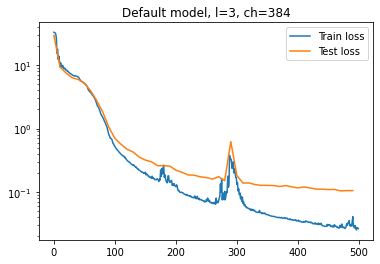

In [8]:
model1.train_model()
model1.plot_losses()

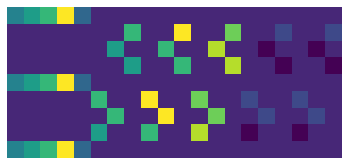

In [9]:
model2 = InertiaModel('Default rep, No hidden layer')
model2.create_EMLP_model(rep_in,rep_out,group=G,num_layers=0)
vis(rep_in(G),rep_out(G))

  0%|          | 0/500 [00:00<?, ?it/s]

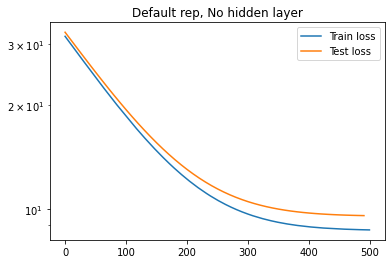

In [10]:
model2.train_model()
model2.plot_losses()

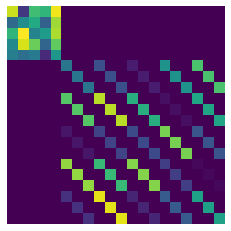

In [11]:
model3 = InertiaModel('Default rep in all hidden layers, l=3, ch=384')
model3.create_EMLP_model(rep_in,rep_out,group=G,num_layers=3,ch=rep_in)
vis(rep_in(G),rep_in(G))

  0%|          | 0/500 [00:00<?, ?it/s]

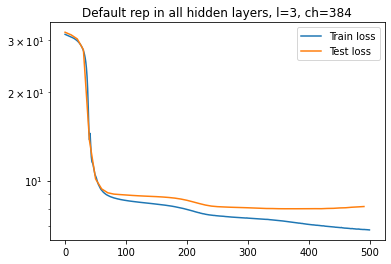

In [12]:
model3.train_model()
model3.plot_losses()

23V⁰+6V+V²


/usr/local/lib/python3.7/dist-packages/emlp/reps/representation.py:473: ConvergenceWarning: Number of distinct clusters (478) found smaller than n_clusters (480). Possibly due to duplicate points in X.
  v = KMeans(n_clusters=Q.shape[-1]).fit(v.reshape(-1,1)).labels_


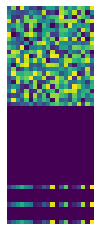

In [13]:
print(uniform_rep(50,G))
vis(rep_scalar(G),uniform_rep(50,G))
model4 = InertiaModel('Only scalars as input rep, l=3, ch=50')
model4.create_EMLP_model(rep_scalar,rep_out,group=G,num_layers=3,ch=50)
model4default = InertiaModel('Default input rep, l=3, ch=50')
model4default.create_EMLP_model(rep_in,rep_out,group=G,num_layers=3,ch=50)

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

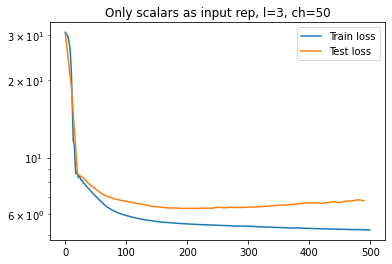

In [14]:
model4.train_model()
model4default.train_model()
model4.plot_losses()

In [15]:
model5 = InertiaModel('Default model, l=3, ch=1000')
model5.create_EMLP_model(rep_in,rep_out,group=G,num_layers=3,ch=1000)
print(uniform_rep(1000,G))
vis(rep_in(G),uniform_rep(1000,G))

Krylov Solving for Equivariant Subspace r<=10:   0%|          | 0/100 [00:00<?, ?it/s]

Krylov Solving for Equivariant Subspace r<=20:   0%|          | 0/100 [00:00<?, ?it/s]

Krylov Solving for Equivariant Subspace r<=40:   0%|          | 0/100 [00:00<?, ?it/s]

Krylov Solving for Equivariant Subspace r<=80:   0%|          | 0/100 [00:00<?, ?it/s]

Krylov Solving for Equivariant Subspace r<=160:   0%|          | 0/100 [00:00<?, ?it/s]

217V⁰+72V+24V²+7V³+2V⁴


  0%|          | 0/500 [00:00<?, ?it/s]

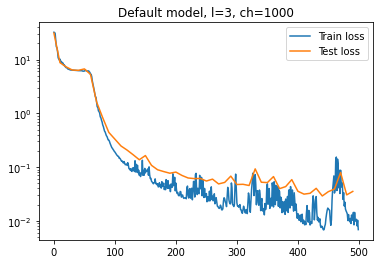

In [16]:
model5.train_model()
model5.plot_losses()

  0%|          | 0/500 [00:00<?, ?it/s]

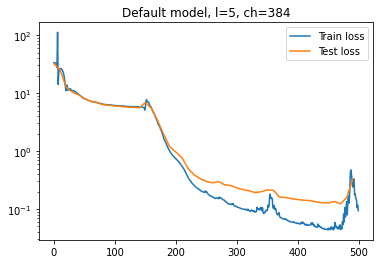

In [29]:
model6a = InertiaModel('Default model, l=5, ch=384')
model6a.create_EMLP_model(rep_in,rep_out,group=G,num_layers=5,ch=384)
model6a.train_model()
model6a.plot_losses()

  0%|          | 0/500 [00:00<?, ?it/s]

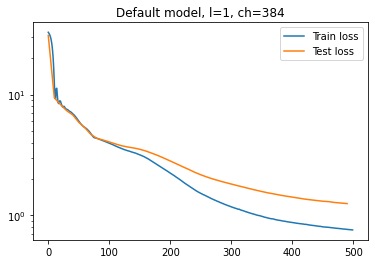

In [22]:
model7 = InertiaModel('Default model, l=1, ch=384')
model7.create_EMLP_model(rep_in,rep_out,group=G,num_layers=1,ch=384)
model7.train_model()
model7.plot_losses()

  0%|          | 0/500 [00:00<?, ?it/s]

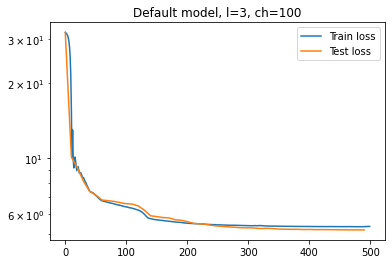

In [30]:
model8 = InertiaModel('Default model, l=3, ch=100')
model8.create_EMLP_model(rep_in,rep_out,group=G,num_layers=3,ch=100)
model8.train_model()
model8.plot_losses()

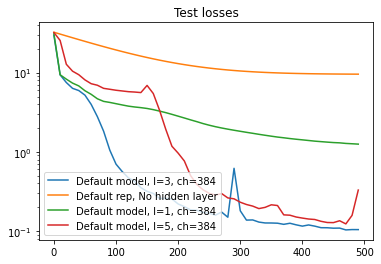

In [31]:
model1.plot_test_loss()
model2.plot_test_loss()
model7.plot_test_loss()
model6a.plot_test_loss()

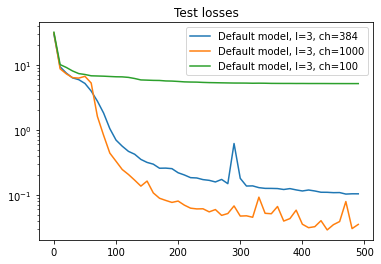

In [32]:
model1.plot_test_loss()
model5.plot_test_loss()
model8.plot_test_loss()

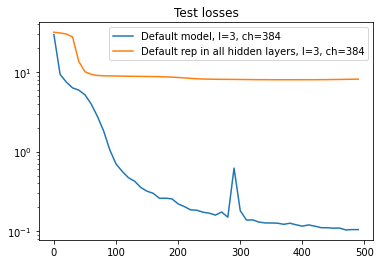

In [26]:
model1.plot_test_loss()
model3.plot_test_loss()

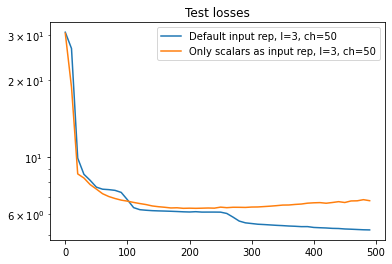

In [27]:
model4default.plot_test_loss()
model4.plot_test_loss()